This notebook is for looking at the results of the tuning experiments.

In [1]:
# polars cant do hive partioning with json stuff
from pathlib import Path
from birdclef.spark import get_spark
import matplotlib.pyplot as plt

scratch = Path("~/scratch/birdclef/2025v2").expanduser()

spark = get_spark()


def show_results(path):
    score = (
        spark.read.json(
            f"{path}/logistic/train",
            multiLine=True,
        )
        .where("_corrupt_record IS NULL")
        .drop("_corrupt_record")
        .orderBy("tokenizer_n_clusters")
        .withColumnRenamed("tokenizer_n_clusters", "n_clusters")
    )
    # score.show()

    timing = (
        spark.read.json(
            f"{path}/word2vec",
            multiLine=True,
        )
        .where("_corrupt_record IS NULL")
        .drop("_corrupt_record")
    )
    # timing.show()
    combined = score.join(
        timing,
        on=list(set(timing.columns).intersection(set(score.columns))),
        how="inner",
    )
    combined.show(n=100)
    return combined


tokenizer = show_results(f"{scratch}/mel2vec-tune/tune-tokenizer")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/05 02:35:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/05 02:35:13 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
25/07/05 02:35:19 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+------+----------+------+-----------+------+-------------+-----------+-------------------+-------------------+-------------------+------------------+------------------+-------+
|epochs|n_clusters|sample|vector_size|window|    tokenizer|ns_exponent|           accuracy|     f1_macro_score|     f1_micro_score|           roc_auc|              time|workers|
+------+----------+------+-----------+------+-------------+-----------+-------------------+-------------------+-------------------+------------------+------------------+-------+
|    20|      4096|1.0E-4|        256|    80|tokenizer_pca|       0.75| 0.4786010124252186|0.41316376685187695| 0.4786010124252186|0.9166063774276413|424.65154868364334|      8|
|    20|     32767|1.0E-4|        256|    80|    tokenizer|       0.75| 0.4592728946157386|0.43556652775913995| 0.4592728946157386|0.9075945009497659|483.21450604405254|      8|
|    20|     32767|1.0E-4|        256|    80|tokenizer_pca|       0.75|0.48619420156465715| 0.4680946922185953

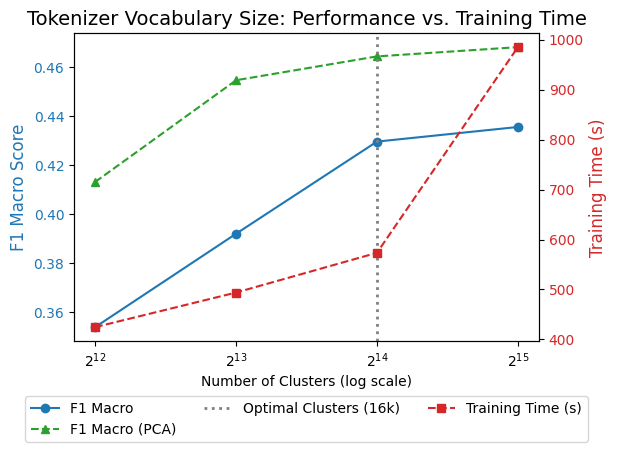

In [4]:
from pyspark.sql import functions as F

df = tokenizer.where(F.col("tokenizer") == "tokenizer").toPandas()
df = df.sort_values(by="n_clusters").reset_index(drop=True)
df_pca = tokenizer.where(F.col("tokenizer") == "tokenizer_pca").toPandas()
df_pca = df_pca.sort_values(by="n_clusters").reset_index(drop=True)

# Create plot
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot F1 Score on the primary y-axis
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (log scale)")
ax1.set_ylabel("F1 Macro Score", color=color, fontsize=12)
ax1.plot(
    df["n_clusters"],
    df["f1_macro_score"],
    color=color,
    marker="o",
    label="F1 Macro",
)
ax1.plot(
    df_pca["n_clusters"],
    df_pca["f1_macro_score"],
    color="tab:green",
    marker="^",
    linestyle="--",
    label="F1 Macro (PCA)",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xscale("log", base=2)

# Instantiate a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Training Time (s)", color=color, fontsize=12)
ax2.plot(
    df_pca["n_clusters"],
    df_pca["time"],
    color=color,
    marker="s",
    linestyle="--",
    label="Training Time (s)",
)
ax2.tick_params(axis="y", labelcolor=color)

# Highlight the optimal point
ax1.axvline(
    x=16383, color="grey", linestyle=":", linewidth=2, label="Optimal Clusters (16k)"
)

# Final touches
plt.title("Tokenizer Vocabulary Size: Performance vs. Training Time", fontsize=14)
# Consolidate legends from both axes into one.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2,
    labels + labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
)

# fig.tight_layout()

fig.set_size_inches(6, 4)
plt.savefig("tokenizer_vocab_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
search = show_results(f"{scratch}/mel2vec-tune/tune-w2v")

25/07/05 02:37:40 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+------+----------+------+-----------+------+-------------+-----------+-------------------+-------------------+-------------------+------------------+------------------+-------+
|epochs|n_clusters|sample|vector_size|window|    tokenizer|ns_exponent|           accuracy|     f1_macro_score|     f1_micro_score|           roc_auc|              time|workers|
+------+----------+------+-----------+------+-------------+-----------+-------------------+-------------------+-------------------+------------------+------------------+-------+
|    20|     16383|1.0E-5|        384|   120|    tokenizer|       -0.5| 0.5080533824206167|0.45441080012423984| 0.5080533824206167|   0.9212191384173|1321.4843244506046|      8|
|    20|     16383|1.0E-5|        384|   120|    tokenizer|        1.5| 0.4986194201564657| 0.4439896800260822| 0.4986194201564657|0.9219874278990631|1235.5519495676272|      8|
|    20|     16383|1.0E-5|        384|    80|    tokenizer|       -0.5|0.49769903359410955| 0.4510355081138121

In [6]:
ns = show_results(f"{scratch}/mel2vec-tune/tune-ns")

25/07/05 02:37:49 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+------+----------+------+-----------+------+-------------+-----------+------------------+-------------------+------------------+------------------+------------------+-------+
|epochs|n_clusters|sample|vector_size|window|    tokenizer|ns_exponent|          accuracy|     f1_macro_score|    f1_micro_score|           roc_auc|              time|workers|
+------+----------+------+-----------+------+-------------+-----------+------------------+-------------------+------------------+------------------+------------------+-------+
|    20|     16383|1.0E-4|        384|    80|tokenizer_pca|      -1.25| 0.534054302807179|0.49427755386918626| 0.534054302807179|0.9311225315405572| 793.1091423407197|      8|
|    20|     16383|1.0E-4|        384|    80|tokenizer_pca|       -1.0|0.5236999539806719| 0.4810295925646092|0.5236999539806719|0.9327644397607289|1099.6830908590928|      8|
|    20|     16383|1.0E-4|        384|    80|tokenizer_pca|      -0.75|0.5310630464795214| 0.5160040479108555|0.53106304

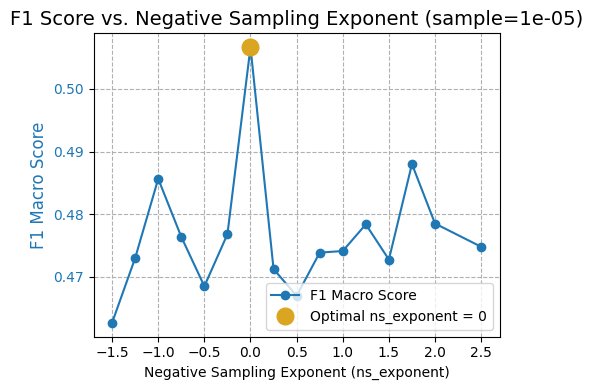

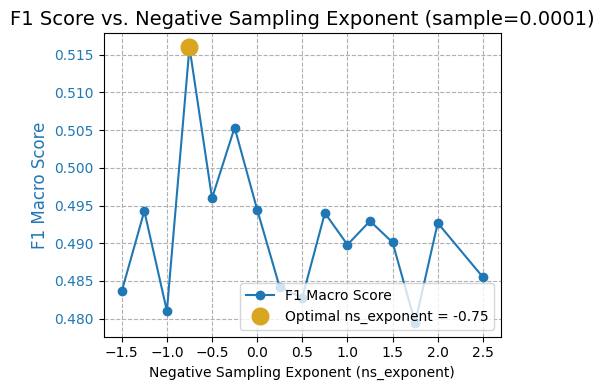

In [9]:
for sample in [1e-5, 1e-4]:
    df = ns.where(F.col("sample") == sample).toPandas()
    # Sort by ns_exponent to ensure the line plot connects points correctly
    df = df.sort_values(by="ns_exponent").reset_index(drop=True)

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Plot F1 Score
    color = "tab:blue"
    ax1.set_xlabel("Negative Sampling Exponent (ns_exponent)")
    ax1.set_ylabel("F1 Macro Score", color=color, fontsize=12)
    ax1.plot(
        df["ns_exponent"],
        df["f1_macro_score"],
        color=color,
        marker="o",
        label="F1 Macro Score",
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.grid(True, which="both", linestyle="--")

    # Highlight the optimal point
    optimal_ns = 0 if sample == 1e-5 else -0.75
    optimal_f1 = df[df["ns_exponent"] == optimal_ns]["f1_macro_score"].iloc[0]
    ax1.plot(
        optimal_ns,
        optimal_f1,
        "o",
        markersize=12,
        color="goldenrod",
        label=f"Optimal ns_exponent = {optimal_ns}",
    )

    # Final Touches
    plt.title(f"F1 Score vs. Negative Sampling Exponent (sample={sample})", fontsize=14)
    ax1.legend(loc="lower right")

    fig.tight_layout()
    fig.set_size_inches(5, 4)
    plt.savefig(f"ns_exponent_tuning_plot_{sample}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [8]:
v2 = show_results(f"{scratch}/mel2vec-v2")

25/07/04 04:37:36 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+------+------+-------------+------+-----------+-----------+----------+------------------+-------------------+------------------+------------------+-----------------+-------+
|window|epochs|    tokenizer|sample|vector_size|ns_exponent|n_clusters|          accuracy|     f1_macro_score|    f1_micro_score|           roc_auc|             time|workers|
+------+------+-------------+------+-----------+-----------+----------+------------------+-------------------+------------------+------------------+-----------------+-------+
|    80|   100|tokenizer_pca|1.0E-5|       1024|        1.5|     16383| 0.601702715140359|  0.540160700220848| 0.601702715140359|0.9481453190393241|815.0928774494678|     16|
|    80|    50|tokenizer_pca|1.0E-5|       1024|        1.5|     16383|0.5897376898297285| 0.5554945871617968|0.5897376898297285|0.9454841489787414|867.4990158136934|     16|
|    80|    60|tokenizer_pca|1.0E-5|       1024|        1.5|     16383|0.5941095260009204| 0.5578208326816797|0.5941095260009

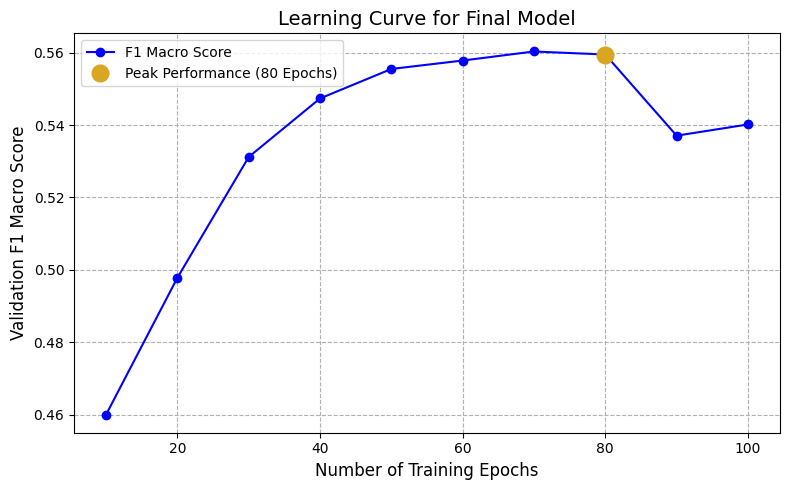

In [10]:
df = v2.toPandas()

# Sort by epochs to create a smooth curve
df = df.sort_values(by="epochs").reset_index(drop=True)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot F1 Score vs. Epochs
ax.plot(
    df["epochs"],
    df["f1_macro_score"],
    marker="o",
    linestyle="-",
    color="b",
    label="F1 Macro Score",
)

# Highlight the optimal point
optimal_epoch = 80
optimal_f1 = df[df["epochs"] == optimal_epoch]["f1_macro_score"].iloc[0]
ax.plot(
    optimal_epoch,
    optimal_f1,
    "o",
    markersize=12,
    color="goldenrod",
    label="Peak Performance (80 Epochs)",
)

# Labels and Title
ax.set_xlabel("Number of Training Epochs", fontsize=12)
ax.set_ylabel("Validation F1 Macro Score", fontsize=12)
ax.set_title("Learning Curve for Final Model", fontsize=14)
ax.legend()
ax.grid(True, which="both", linestyle="--")

plt.tight_layout()